## DDIM 기초 구현

### 구현해야될 항목
- DDIM sampling 코드
  - 기본 모델은 ddpm의 가중치를 이용할 예정


### 라이브러리

In [1]:
from tqdm import tqdm
import numpy as np

# torch
import torch
import torch.nn as nn
from torch.nn import init
import torch.nn.functional as F
import math

# dataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
import torchvision.utils as vutils

# visualization
import cv2
import matplotlib.pyplot as plt
import imageio

# check cuda
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    torch.device("cpu")
print(" Device: ", device)
# !pip install opencv-python
# !pip install imageio

 Device:  cuda:0


### 기본 계수 코드

In [2]:
# time t
T = 1000 

# beta: linear하게 증가
betas = torch.linspace(1e-4, 0.02, T).to(device) 

# alpha는 beta의 변형이므로
alphas = 1 - betas

# alpha bar는 alhpa의 누적 합 -> torch의 cumprod 함수
alphas_bar = torch.cumprod(alphas, dim = 0, ).to(device)

# alpha bar 의 t-1도 sampling 과정에서 필요하다. 
# 맨 처음에 alpha가 하나도 없었다는 뜻으로 맨 앞에 1을 추가.
alphas_bar_prev = F.pad(alphas_bar[:-1], (1, 0), value = 1)

#training에 필요한 변수
sqrt_alphas_bar = torch.sqrt(alphas_bar).to(device)
sqrt_one_minus_alphas_bar = torch.sqrt(1. - alphas_bar).to(device)

# sampling에 필요한 변수
reciprocal_alphas_sqrt = torch.sqrt(1. / alphas_bar).to(device)
reciprocal_alphasm1_sqrt = torch.sqrt(1. / alphas_bar - 1.).to(device)
posterior_mean_coef1 = torch.sqrt(alphas_bar_prev) * betas / (1. - alphas_bar).to(device)
posterior_mean_coef2 = torch.sqrt(alphas) * (1. - alphas_bar_prev) / (1. - alphas_bar).to(device)
sigmas = (betas * (1. - alphas_bar_prev) / (1. - alphas_bar)).to(device) # 시그마는 betas를 사용해도 무관함

### DDIM 샘플링 코드
   
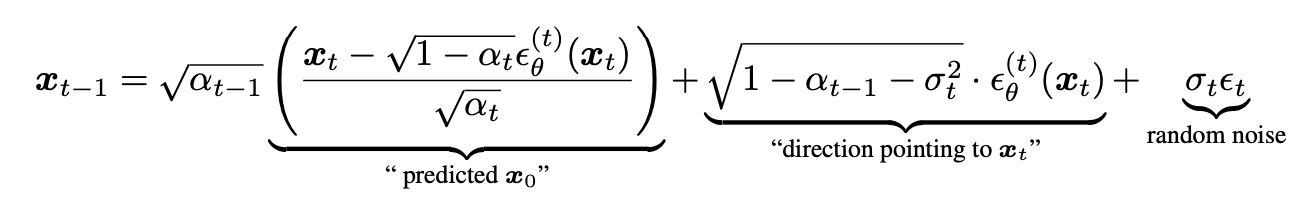

In [84]:
#기존
def gather_and_expand(coeff, t, xshape):
    ''' 
    t시간에 해당하는 계수(인덱스)를 계수 텐서(coeff)에서 가져오고, 
    해당 계수들을 batch size에 맞게 확장하는 함수 
    '''
    # 입력 텐서의 차원 분리
    batch_size, *dims = xshape # batch_size는 첫 번째 차원, dims는 나머지 차원

     # t시간에 해당하는 계수 가져오기
    coeff_t = torch.gather(coeff, index = t, dim = 0) # Shape: (len(t), ) = (batch_size, )
    
    # 차원 확장
    coeff_t = coeff_t.view([batch_size] + [1] * len(dims)) # 나머지 차원들에 맞게 확장 -> 이후의 계산 차원을 맞추기 위하여
    return coeff_t
    
def sample(model, x_T, step_size = 20 ,save_rate = 50): # x_T: noisy data
    x_t = x_T
    samples = []
    i = 0
    for time_step in range(T-1, -1, -step_size): # T , ..., 1 반복 수행
        # 각 time_step를 batch size로 확장
        t = torch.full((x_T.shape[0], ), time_step, dtype=torch.long, device=device)
        print(t)
        print(t.shape)
        # 업데이트 과정
        eps = model(x_t, t) # 모델 예측
        print(time_step)
        term1 = torch.sqrt(alphas_bar_prev[time_step]) / sqrt_alphas_bar[time_step] * (x_t - sqrt_one_minus_alphas_bar[time_step] * eps)
        term2 = torch.sqrt(1 - alphas_bar_prev[time_step]) * eps

        x_t = term1 + term2  # 예측된 x0에 방향성 노이즈를 더한 값을 반환
        i += 1
        
        # sampling gif 만들기
        if i % 10 == 0 or time_step < 7 * step_size:
            grid = vutils.make_grid(x_t, nrow=5, padding=3) # grid 만들기 (C, H, W)
            grid = grid.permute(1, 2, 0).clamp(0, 1).cpu().numpy() * 255 # grid: (H, W, C)
            grid = grid.astype(np.uint8)
            samples.append(grid)
        
    # print('final',len(samples))
    imageio.mimsave(f"sample/ddim-sampling-epoch-{step_size}.gif", samples, fps=40)
    # 마지막 결과 return 
    x_0 = x_t
    return x_0

In [85]:
# #기존
# def gather_and_expand(coeff, t, xshape):
#     ''' 
#     t시간에 해당하는 계수(인덱스)를 계수 텐서(coeff)에서 가져오고, 
#     해당 계수들을 batch size에 맞게 확장하는 함수 
#     '''
#     # 입력 텐서의 차원 분리
#     batch_size, *dims = xshape # batch_size는 첫 번째 차원, dims는 나머지 차원

#      # t시간에 해당하는 계수 가져오기
#     coeff_t = torch.gather(coeff, index = t, dim = 0) # Shape: (len(t), ) = (batch_size, )
    
#     # 차원 확장
#     coeff_t = coeff_t.view([batch_size] + [1] * len(dims)) # 나머지 차원들에 맞게 확장 -> 이후의 계산 차원을 맞추기 위하여
#     return coeff_t
    
# def sample(model, x_T, n = 20 ,save_rate = 50): # x_T: noisy data
#     x_t = x_T
#     samples = []
#     # for time_step in reversed(range(T)): # T , ..., 1 반복 수행
#     step_size = T // n
#     for time_step in range(T-1, -1, -step_size): # T , ..., 1 반복 수행
#         # 각 time_step를 batch size로 확장
#         t = torch.full((x_T.shape[0], ), time_step, dtype=torch.long, device=device)
        
#         # 업데이트 과정
#         eps = model(x_t, t) # 모델 예측
#         # pred_x0 = (x_t - (gather_and_expand(sqrt_one_minus_alphas_bar, t, eps.shape) * eps)) /  gather_and_expand(sqrt_alphas_bar, t, eps.shape) 
#         # term1 = gather_and_expand(torch.sqrt(alphas_bar_prev), t, eps.shape) * pred_x0 # 예측된 x0
#         # pred_x0 = 
#         term1 = gather_and_expand(torch.sqrt(alphas_bar_prev), t, eps.shape) /  gather_and_expand(sqrt_alphas_bar, t, eps.shape) \
#                      * (x_t - (gather_and_expand(sqrt_one_minus_alphas_bar, t, eps.shape) * eps)) 
#         print(term1.shape)
#         term2 = torch.sqrt(1 - gather_and_expand(alphas_bar_prev , t, eps.shape)) * eps # 방향성 노이즈
#         x_t = term1 + term2  # 예측된 x0에 방향성 노이즈를 더한 값을 반환
#         print(x_t[0])
#         print('-'*100)
#         print(x_t[1])
#         print()
#         # sampling gif 만들기
#         grid = vutils.make_grid(x_t, nrow=5, padding=3) # grid 만들기 (C, H, W)
#         grid = grid.permute(1, 2, 0).clamp(0, 1).cpu().numpy() * 255 # grid: (H, W, C)
#         grid = grid.astype(np.uint8)
#         samples.append(grid)
            
#     imageio.mimsave(f"sample/ddim-sampling-epoch-{T // step_size}.gif", samples, fps=10)
#     # 마지막 결과 return 
#     x_0 = x_t
#     return x_0

# **Model architecture**

https://github.com/w86763777/pytorch-ddpm/blob/master/model.py

위 github에서 copy함(\_\_name\_\_ == "\_\_name\_\_" 제외)

In [86]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class TimeEmbedding(nn.Module):
    def __init__(self, T, d_model, dim):
        assert d_model % 2 == 0
        super().__init__()
        emb = torch.arange(0, d_model, step=2) / d_model * math.log(10000)
        emb = torch.exp(-emb)
        pos = torch.arange(T).float()
        emb = pos[:, None] * emb[None, :]
        emb = torch.stack([torch.sin(emb), torch.cos(emb)], dim=-1)
        emb = emb.view(T, d_model)

        self.timembedding = nn.Sequential(
            nn.Embedding.from_pretrained(emb),
            nn.Linear(d_model, dim),
            Swish(),
            nn.Linear(dim, dim),
        )
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                init.xavier_uniform_(module.weight)
                init.zeros_(module.bias)

    def forward(self, t):
        emb = self.timembedding(t)
        return emb

class DownSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.main = nn.Conv2d(in_ch, in_ch, 3, stride=2, padding=1)
        self.initialize()

    def initialize(self):
        init.xavier_uniform_(self.main.weight)
        init.zeros_(self.main.bias)

    def forward(self, x, temb):
        x = self.main(x)
        return x

class UpSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.main = nn.Conv2d(in_ch, in_ch, 3, stride=1, padding=1)
        self.initialize()

    def initialize(self):
        init.xavier_uniform_(self.main.weight)
        init.zeros_(self.main.bias)

    def forward(self, x, temb):
        _, _, H, W = x.shape
        x = F.interpolate(
            x, scale_factor=2, mode='nearest')
        x = self.main(x)
        return x

class AttnBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.group_norm = nn.GroupNorm(32, in_ch)
        self.proj_q = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_k = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_v = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.initialize()

    def initialize(self):
        for module in [self.proj_q, self.proj_k, self.proj_v, self.proj]:
            init.xavier_uniform_(module.weight)
            init.zeros_(module.bias)
        init.xavier_uniform_(self.proj.weight, gain=1e-5)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.group_norm(x)
        q = self.proj_q(h)
        k = self.proj_k(h)
        v = self.proj_v(h)

        q = q.permute(0, 2, 3, 1).view(B, H * W, C)
        k = k.view(B, C, H * W)
        w = torch.bmm(q, k) * (int(C) ** (-0.5))
        assert list(w.shape) == [B, H * W, H * W]
        w = F.softmax(w, dim=-1)

        v = v.permute(0, 2, 3, 1).view(B, H * W, C)
        h = torch.bmm(w, v)
        assert list(h.shape) == [B, H * W, C]
        h = h.view(B, H, W, C).permute(0, 3, 1, 2)
        h = self.proj(h)

        return x + h

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, dropout, attn=False):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(32, in_ch),
            Swish(),
            nn.Conv2d(in_ch, out_ch, 3, stride=1, padding=1),
        )
        self.temb_proj = nn.Sequential(
            Swish(),
            nn.Linear(tdim, out_ch),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(32, out_ch),
            Swish(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1),
        )
        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=1, padding=0)
        else:
            self.shortcut = nn.Identity()
        if attn:
            self.attn = AttnBlock(out_ch)
        else:
            self.attn = nn.Identity()
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                init.xavier_uniform_(module.weight)
                init.zeros_(module.bias)
        init.xavier_uniform_(self.block2[-1].weight, gain=1e-5)

    def forward(self, x, temb):
        h = self.block1(x)
        h += self.temb_proj(temb)[:, :, None, None]
        h = self.block2(h)

        h = h + self.shortcut(x)
        h = self.attn(h)
        return h

class UNet(nn.Module):
    def __init__(self, T, ch, ch_mult, attn, num_res_blocks, dropout):
        super().__init__()
        assert all([i < len(ch_mult) for i in attn]), 'attn index out of bound'
        tdim = ch * 4
        self.time_embedding = TimeEmbedding(T, ch, tdim)

        self.head = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.downblocks = nn.ModuleList()
        chs = [ch]  # record output channel when dowmsample for upsample
        now_ch = ch
        for i, mult in enumerate(ch_mult):
            out_ch = ch * mult
            for _ in range(num_res_blocks):
                self.downblocks.append(ResBlock(
                    in_ch=now_ch, out_ch=out_ch, tdim=tdim,
                    dropout=dropout, attn=(i in attn)))
                now_ch = out_ch
                chs.append(now_ch)
            if i != len(ch_mult) - 1:
                self.downblocks.append(DownSample(now_ch))
                chs.append(now_ch)

        self.middleblocks = nn.ModuleList([
            ResBlock(now_ch, now_ch, tdim, dropout, attn=True),
            ResBlock(now_ch, now_ch, tdim, dropout, attn=False),
        ])

        self.upblocks = nn.ModuleList()
        for i, mult in reversed(list(enumerate(ch_mult))):
            out_ch = ch * mult
            for _ in range(num_res_blocks + 1):
                self.upblocks.append(ResBlock(
                    in_ch=chs.pop() + now_ch, out_ch=out_ch, tdim=tdim,
                    dropout=dropout, attn=(i in attn)))
                now_ch = out_ch
            if i != 0:
                self.upblocks.append(UpSample(now_ch))
        assert len(chs) == 0

        self.tail = nn.Sequential(
            nn.GroupNorm(32, now_ch),
            Swish(),
            nn.Conv2d(now_ch, 3, 3, stride=1, padding=1)
        )
        self.initialize()

    def initialize(self):
        init.xavier_uniform_(self.head.weight)
        init.zeros_(self.head.bias)
        init.xavier_uniform_(self.tail[-1].weight, gain=1e-5)
        init.zeros_(self.tail[-1].bias)

    def forward(self, x, t):
        # Timestep embedding
        temb = self.time_embedding(t)
        # Downsampling
        h = self.head(x)
        hs = [h]
        for layer in self.downblocks:
            h = layer(h, temb)
            hs.append(h)
        # Middle
        for layer in self.middleblocks:
            h = layer(h, temb)
        # Upsampling
        for layer in self.upblocks:
            if isinstance(layer, ResBlock):
                h = torch.cat([h, hs.pop()], dim=1)
            h = layer(h, temb)
        h = self.tail(h)

        assert len(hs) == 0
        return h

## **Make model,optimizer, scheduler instance**

In [87]:
model = UNet(T=T, ch=128, ch_mult=[1, 2, 2, 1], attn=[1],
             num_res_blocks=2, dropout=0.1).to(device)
#ema_model = copy.deepcopy(model)
optim = torch.optim.Adam(model.parameters(), lr=2e-4)
#sched = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=warmup_lr)

## **Sampling**

tensor([999, 999, 999, 999, 999, 999, 999, 999, 999, 999], device='cuda:0')
torch.Size([10])
999
tensor([997, 997, 997, 997, 997, 997, 997, 997, 997, 997], device='cuda:0')
torch.Size([10])
997
tensor([995, 995, 995, 995, 995, 995, 995, 995, 995, 995], device='cuda:0')
torch.Size([10])
995
tensor([993, 993, 993, 993, 993, 993, 993, 993, 993, 993], device='cuda:0')
torch.Size([10])
993
tensor([991, 991, 991, 991, 991, 991, 991, 991, 991, 991], device='cuda:0')
torch.Size([10])
991
tensor([989, 989, 989, 989, 989, 989, 989, 989, 989, 989], device='cuda:0')
torch.Size([10])
989
tensor([987, 987, 987, 987, 987, 987, 987, 987, 987, 987], device='cuda:0')
torch.Size([10])
987
tensor([985, 985, 985, 985, 985, 985, 985, 985, 985, 985], device='cuda:0')
torch.Size([10])
985
tensor([983, 983, 983, 983, 983, 983, 983, 983, 983, 983], device='cuda:0')
torch.Size([10])
983
tensor([981, 981, 981, 981, 981, 981, 981, 981, 981, 981], device='cuda:0')
torch.Size([10])
981
------------------------------

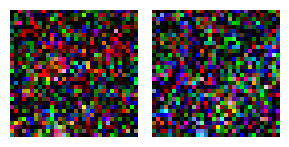

In [89]:
checkpoint_path = "weights/ddpm-model-epoch-100.pth"
# state_dict 로드
state_dict = torch.load(checkpoint_path, weights_only=True, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# 샘플링 수행
with torch.no_grad():
    # 샘플링 시작점 (가우시안 노이즈)
    x_T = torch.randn(10, 3, 32, 32).to(device)

    # 모델로부터 x_0 생성 
    x_0 = sample(model, x_T, step_size = 2)
    
    #    여기서는 B=10 개 중 2개만 확인 예시
    x_0 = x_0.permute(0, 2, 3, 1).clamp(0, 1).detach().cpu().numpy() * 255 #    x_0: (B, C, H, W) -> (B, H, W, C) 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3, 3))  # 1행 2열
    for i in range(2):
        axes[i].imshow(x_0[i].astype(np.uint8))
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()